
# Brain Tumor MRI — Data Engineering & Preprocessing Pipeline

**Dataset:** `masoudnickparvar/brain-tumor-mri-dataset`

**Scope of this notebook**

1. Build a single labeled dataframe from the raw Kaggle folder structure.
2. Stratified **80 / 10 / 10** Train / Val / Test split.
3. Modular preprocessing pipeline:
   - Crop out brain contour (removes black padding around the brain) - `black-threshold=10`
   - Bilateral Filtering (edge-preserving denoise) — `d=9, sigmaColor=75, sigmaSpace=75`
   - CLAHE on the **L-channel in LAB space** — `clipLimit=2.0, tileGridSize=(8,8)`
   - **Z-Score normalization** (mean 0 / std 1) — replaces the old 0–1 min-max scaling
5. **Albumentations** augmentation engine (replacing `ImageDataGenerator`) with:
   - `ElasticTransform` (simulated scanner/tissue elasticity)
   - Small rotations (±10°)
   - Brightness / contrast jitter
6. A custom `tf.keras.utils.Sequence` that wraps the full pipeline for training.
7. Full **visual diagnostics** section: 5-step pipeline grid, intensity histograms, 3×3 augmentation grid.

> This notebook is preprocessing-only — no model is trained here. The output is a ready-to-consume
> `MRIDataSequence` for the Modeling workstream.


## 0. Environment Setup

In [109]:

import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import Sequence, to_categorical

print("TensorFlow :", tf.__version__)
print("Albumentations :", A.__version__)
print("OpenCV :", cv2.__version__)


TensorFlow : 2.20.0
Albumentations : 2.0.8
OpenCV : 4.13.0


## 1. Configuration

In [110]:

class CONFIG:
    # Kaggle mounts the dataset here when attached to the notebook
    RAW_DATA_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

    IMG_SIZE = (224, 224)          # (H, W) target size fed to the network
    CHANNELS = 3                   # pipeline works in 3-channel (LAB/CLAHE needs color)
    NUM_CLASSES = 4
    CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

    # Split ratios (must sum to 1.0)
    TRAIN_RATIO = 0.80
    VAL_RATIO   = 0.10
    TEST_RATIO  = 0.10

    BATCH_SIZE = 32
    SEED = 42

    # --- Preprocessing hyperparameters (per team spec) ---
    BINARY_THRESHOLD_CUTOFF = 10
    
    BILATERAL_D = 5
    BILATERAL_SIGMA_COLOR = 20
    BILATERAL_SIGMA_SPACE = 20

    CLAHE_CLIP_LIMIT = 1.5
    CLAHE_TILE_GRID_SIZE = (4, 4)

    # --- Albumentations hyperparameters ---
    ROTATE_LIMIT_DEG = 10
    ELASTIC_ALPHA = 40
    ELASTIC_SIGMA = 6
    BRIGHTNESS_CONTRAST_LIMIT = 0.15

random.seed(CONFIG.SEED)
np.random.seed(CONFIG.SEED)
tf.random.set_seed(CONFIG.SEED)



## 2. Build the Master DataFrame

The raw Kaggle release ships as `Training/` and `Testing/` folders, each containing one
sub-folder per class. Since we are enforcing our **own** stratified 80/10/10 split,
we pool every image from both folders into a single dataframe and re-split it ourselves
(this avoids inheriting the original, non-stratified train/test boundary).


In [111]:

def build_dataframe(raw_dir: str) -> pd.DataFrame:
    """Walk the Kaggle folder structure and return a filepath/label dataframe."""
    records = []
    search_roots = [os.path.join(raw_dir, "Training"), os.path.join(raw_dir, "Testing")]
    # fallback in case the release uses lowercase / different top-level names
    search_roots = [p for p in search_roots if os.path.isdir(p)] or [raw_dir]

    for root in search_roots:
        for class_name in CONFIG.CLASS_NAMES:
            class_dir = os.path.join(root, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fp in glob.glob(os.path.join(class_dir, "*")):
                if fp.lower().endswith((".jpg", ".jpeg", ".png")):
                    records.append({"filepath": fp, "label": class_name})

    df = pd.DataFrame(records)
    if df.empty:
        raise FileNotFoundError(
            f"No images found under {raw_dir}. Check that the dataset is attached to this notebook."
        )
    return df.reset_index(drop=True)


master_df = build_dataframe(CONFIG.RAW_DATA_DIR)
print(f"Total images found: {len(master_df)}")
master_df["label"].value_counts()


Total images found: 7200


label
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64

## 3. Stratified 80 / 10 / 10 Split

In [112]:

def stratified_three_way_split(df: pd.DataFrame, train_ratio, val_ratio, test_ratio, seed):
    assert abs((train_ratio + val_ratio + test_ratio) - 1.0) < 1e-6, "Ratios must sum to 1.0"

    # Step 1: carve off the training set
    train_df, holdout_df = train_test_split(
        df,
        train_size=train_ratio,
        stratify=df["label"],
        random_state=seed,
    )

    # Step 2: split the remainder proportionally into val / test
    relative_val_ratio = val_ratio / (val_ratio + test_ratio)
    val_df, test_df = train_test_split(
        holdout_df,
        train_size=relative_val_ratio,
        stratify=holdout_df["label"],
        random_state=seed,
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


train_df, val_df, test_df = stratified_three_way_split(
    master_df, CONFIG.TRAIN_RATIO, CONFIG.VAL_RATIO, CONFIG.TEST_RATIO, CONFIG.SEED
)

print(f"Train: {len(train_df):5d}  ({len(train_df)/len(master_df):.1%})")
print(f"Val:   {len(val_df):5d}  ({len(val_df)/len(master_df):.1%})")
print(f"Test:  {len(test_df):5d}  ({len(test_df)/len(master_df):.1%})")

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "val":   val_df["label"].value_counts(),
    "test":  test_df["label"].value_counts(),
}).fillna(0).astype(int)
split_summary


Train:  5760  (80.0%)
Val:     720  (10.0%)
Test:    720  (10.0%)


,train,val,test
label,,,
glioma,1440,180,180
meningioma,1440,180,180
notumor,1440,180,180
pituitary,1440,180,180


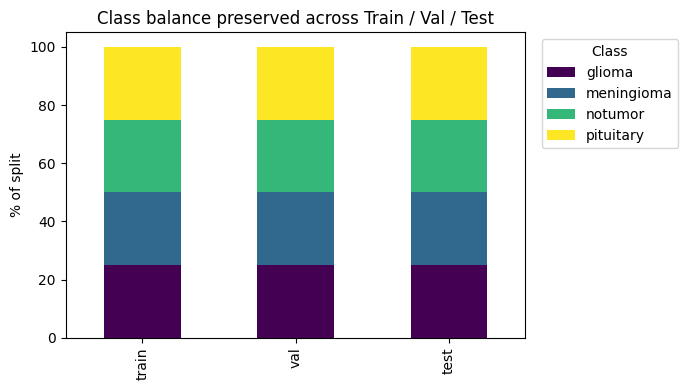

In [113]:

# Quick sanity check: confirm class proportions stayed stable across splits
split_pct = split_summary.div(split_summary.sum(axis=0), axis=1) * 100
ax = split_pct.T.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="viridis")
ax.set_ylabel("% of split")
ax.set_title("Class balance preserved across Train / Val / Test")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



## 4. Modular Preprocessing Functions

Each transform is a small, independently testable function so the pipeline can be
unit-tested, re-ordered, or partially reused (e.g. only CLAHE for a quick-look tool).


In [114]:

def load_image(filepath: str, size=CONFIG.IMG_SIZE) -> np.ndarray:
    """Load an image from disk as RGB uint8, resized to the target shape."""
    bgr = cv2.imread(filepath, cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Could not read image: {filepath}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, size, interpolation=cv2.INTER_AREA)
    return rgb


In [115]:
def crop_brain_contour(img):
    
    """Crops out excess black padding around the head/brain."""
    
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if len(img.shape) == 3 else img
    
    # Threshold to find non-black regions
    _, thresh = cv2.threshold(gray, CONFIG.BINARY_THRESHOLD_CUTOFF, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        return img[y:y+h, x:x+w]
    return img

In [116]:

def apply_bilateral_filter(
    image: np.ndarray,
    d: int = CONFIG.BILATERAL_D,
    sigma_color: float = CONFIG.BILATERAL_SIGMA_COLOR,
    sigma_space: float = CONFIG.BILATERAL_SIGMA_SPACE,
) -> np.ndarray:
    
    """Edge-preserving denoise. Removes MRI scanner speckle/grain while keeping
    tumor/tissue boundaries sharp — critical before any contrast enhancement."""
    
    return cv2.bilateralFilter(image, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)


In [117]:

def apply_clahe_lab(
    image: np.ndarray,
    clip_limit: float = CONFIG.CLAHE_CLIP_LIMIT,
    tile_grid_size=CONFIG.CLAHE_TILE_GRID_SIZE,
) -> np.ndarray:
    
    """Contrast-Limited Adaptive Histogram Equalization applied only to the
    L (lightness) channel in LAB space. This boosts soft-tissue contrast without
    distorting color/chroma information. Hence, a/b channels stay untouched."""
    
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l_channel)

    lab_eq = cv2.merge((l_eq, a_channel, b_channel))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)


In [118]:
def zscore_minmax_normalize(image: np.ndarray, eps: float = 1e-7) -> np.ndarray:
    """
    Standardizes pixel intensities using Z-score (per-image mean/std)
    and linearly rescales the result strictly into the [0.0, 1.0] float32 range.
    
    Retains Z-score intensity alignment while keeping values bounded for CNNs.
    """
    image = image.astype(np.float32)
    
    # 1. Z-Score Normalization (Mean=0, Std=1)
    mean = image.mean()
    std = image.std()
    z_scored = (image - mean) / (std + eps)
    
    # 2. Rescale Z-scored matrix linearly to [0.0, 1.0]
    z_min = z_scored.min()
    z_max = z_scored.max()
    normalized_0_1 = (z_scored - z_min) / (z_max - z_min + eps)
    
    return normalized_0_1

In [119]:

def preprocess_pipeline(image: np.ndarray) -> dict:
    
    """Run the full deterministic preprocessing chain and return every
    intermediate result — used both by the training generator (final key only)
    and by the visual diagnostics section (all intermediate keys)."""

    padding_removed = crop_brain_contour(image)
    denoised = apply_bilateral_filter(padding_removed)
    contrast_enhanced = apply_clahe_lab(denoised)
    normalized = zscore_minmax_normalize(contrast_enhanced)

    return {
        "raw": image,
        "padded": padding_removed,
        "bilateral": denoised,
        "clahe": contrast_enhanced,
        "zscore": normalized,                       # float32, mean 0 / std 1 -> model input
    }


### Visual Comparsson on each stage:

In [120]:
def get_sample_filepath(df: pd.DataFrame, seed=CONFIG.SEED) -> str:
    return df.sample(1, random_state=seed)["filepath"].values[0]

In [121]:
def plot_histogram(ax, image, title, color):
    ax.hist(
        image.ravel(),
        bins=256,
        color=color,
        alpha=0.8
    )

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Pixel value", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(labelsize=7)

Considering 10 random samples from the image set:

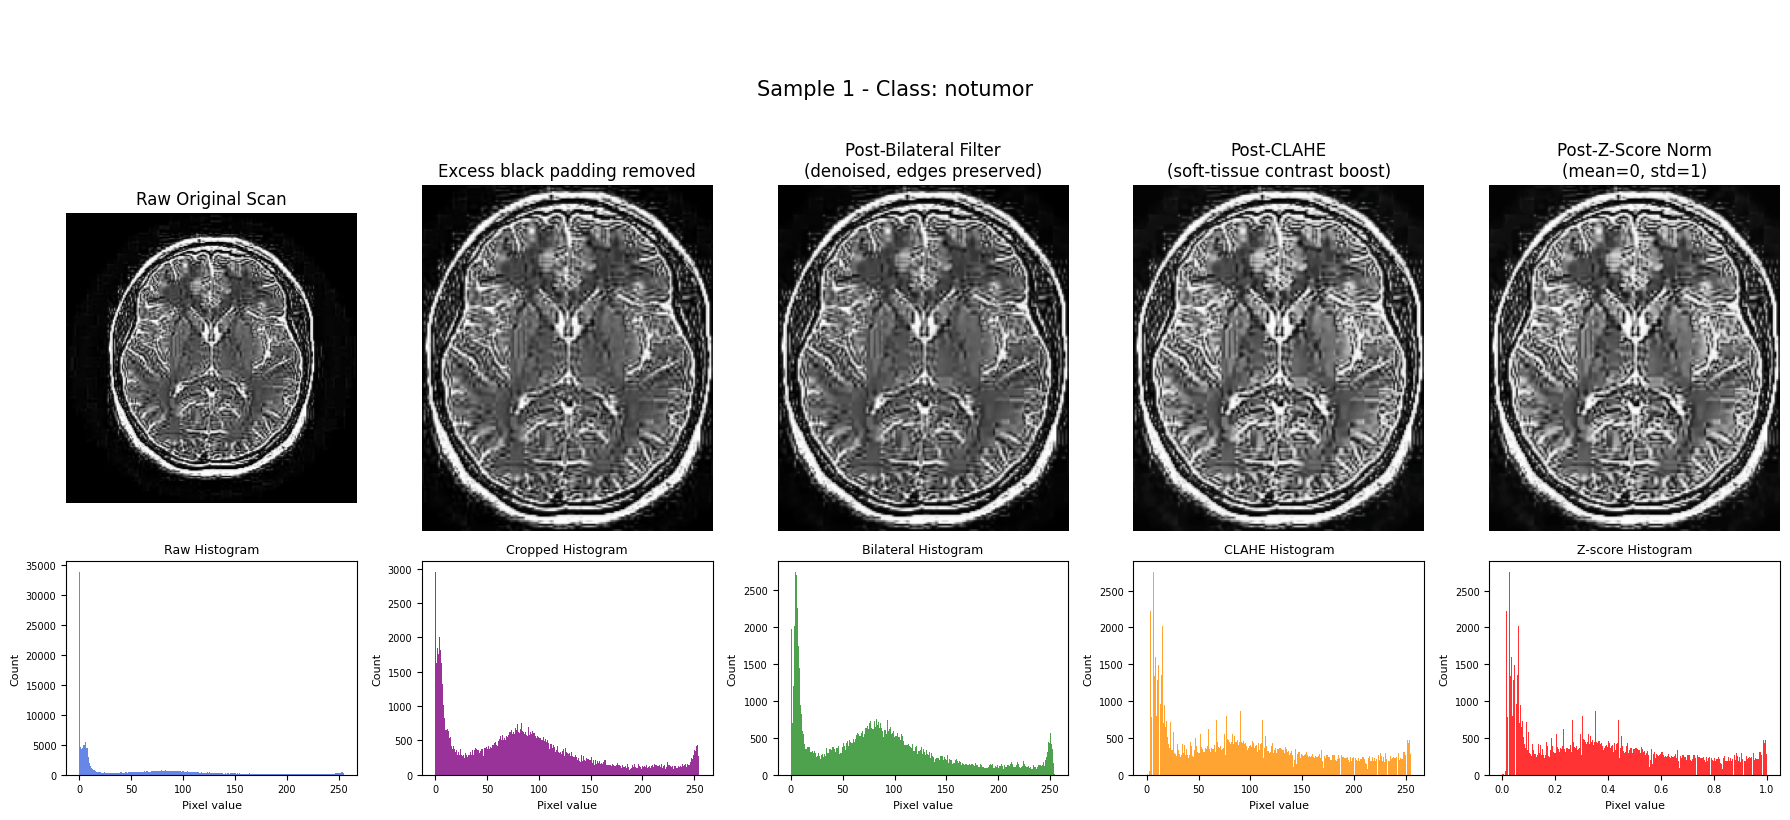

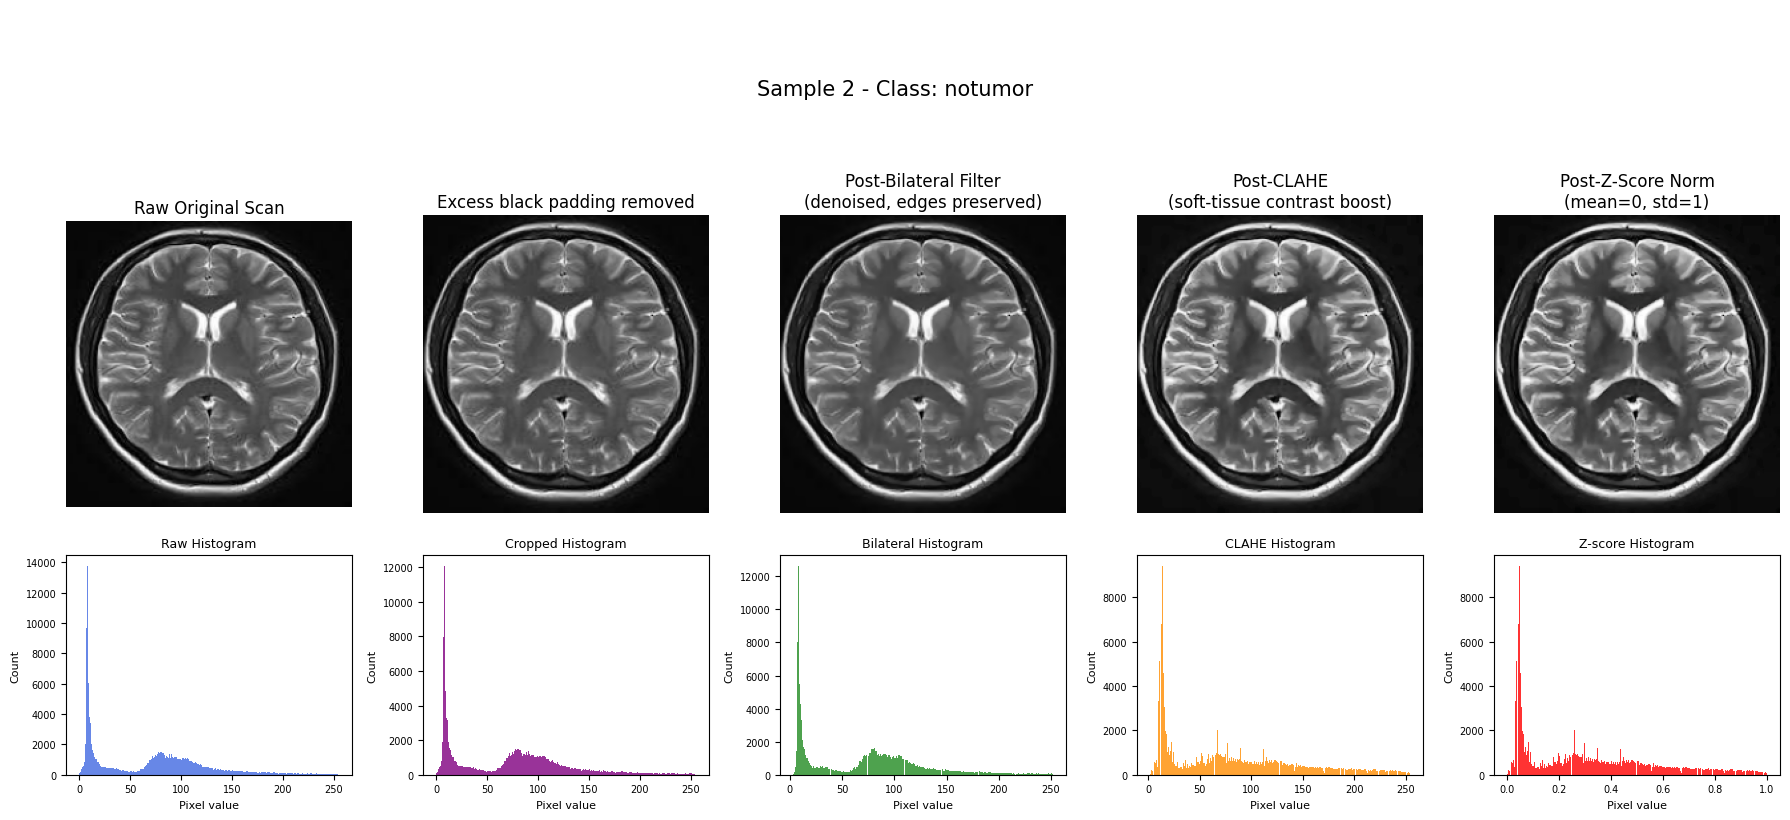

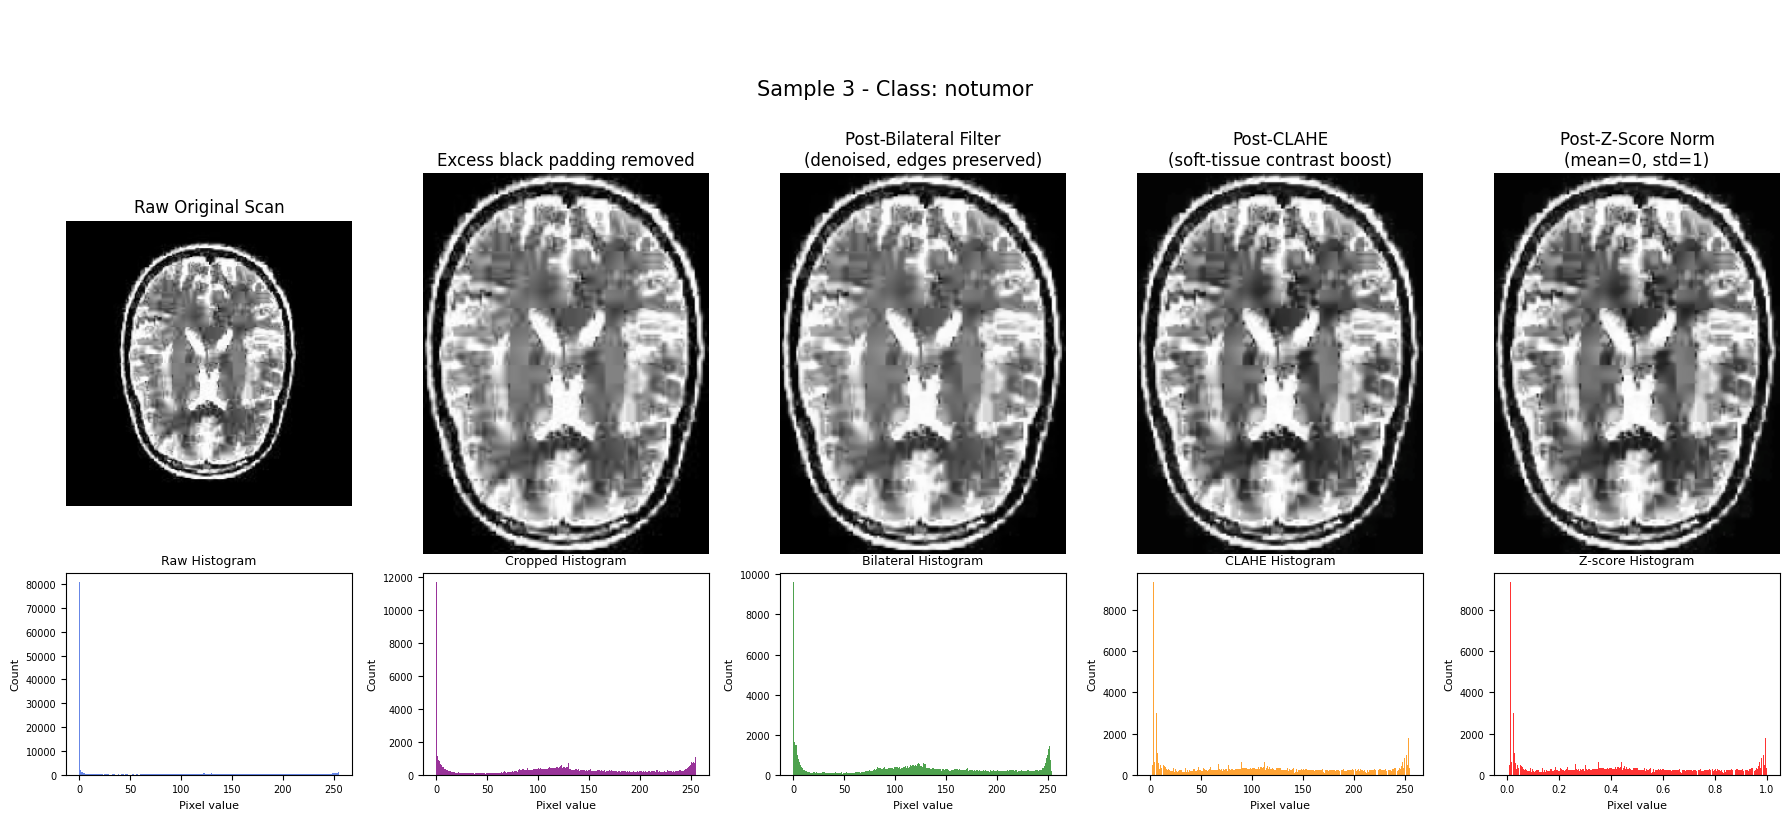

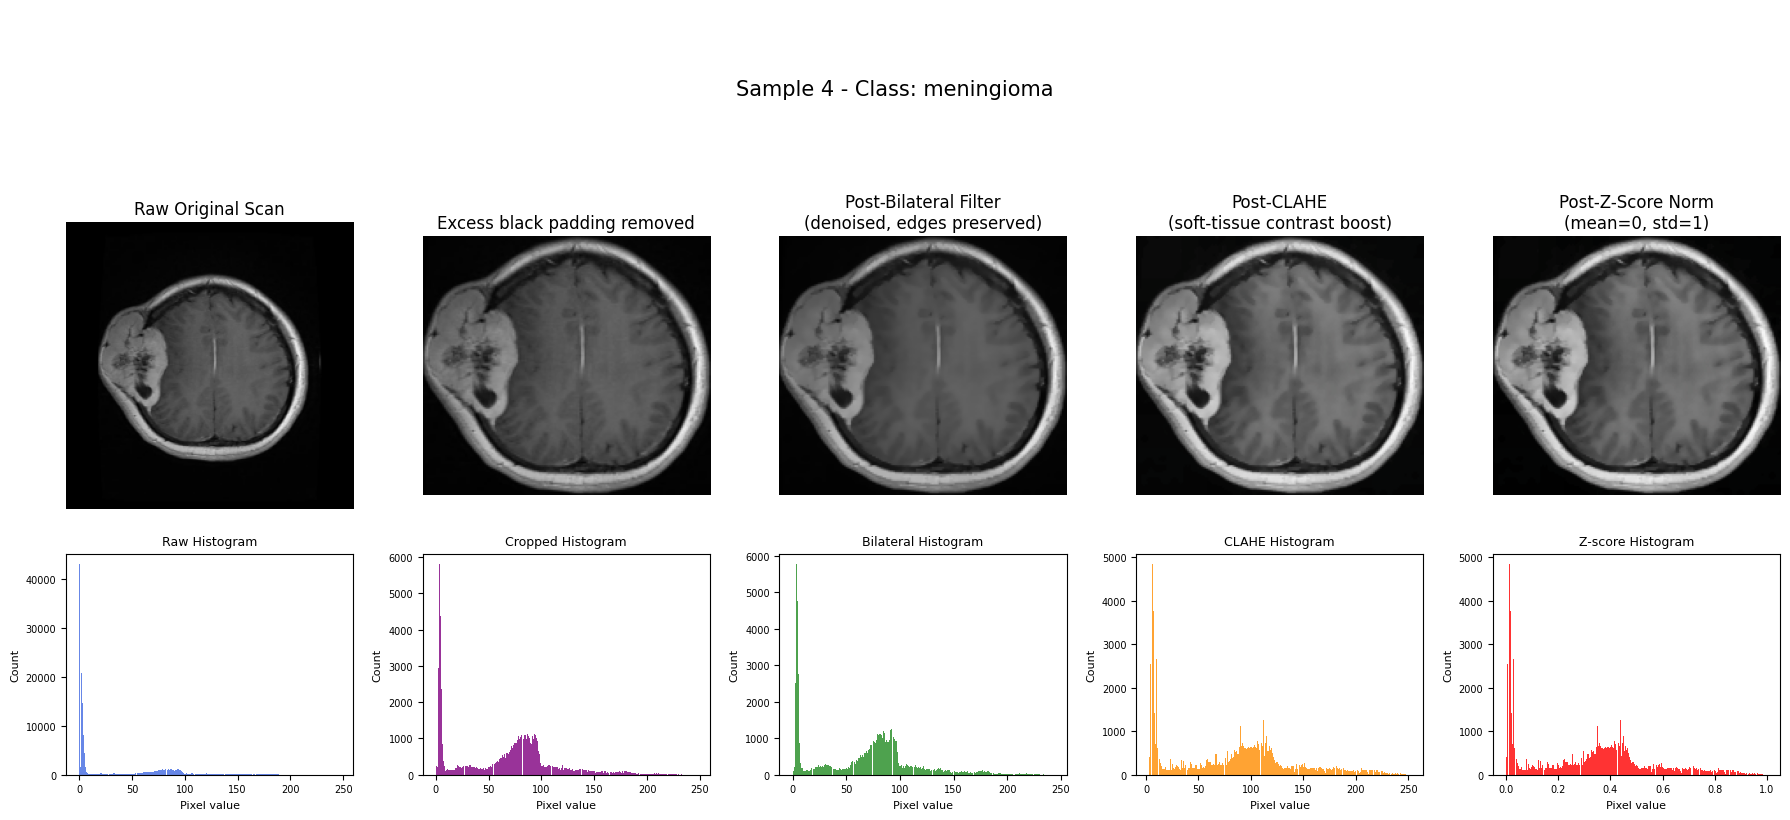

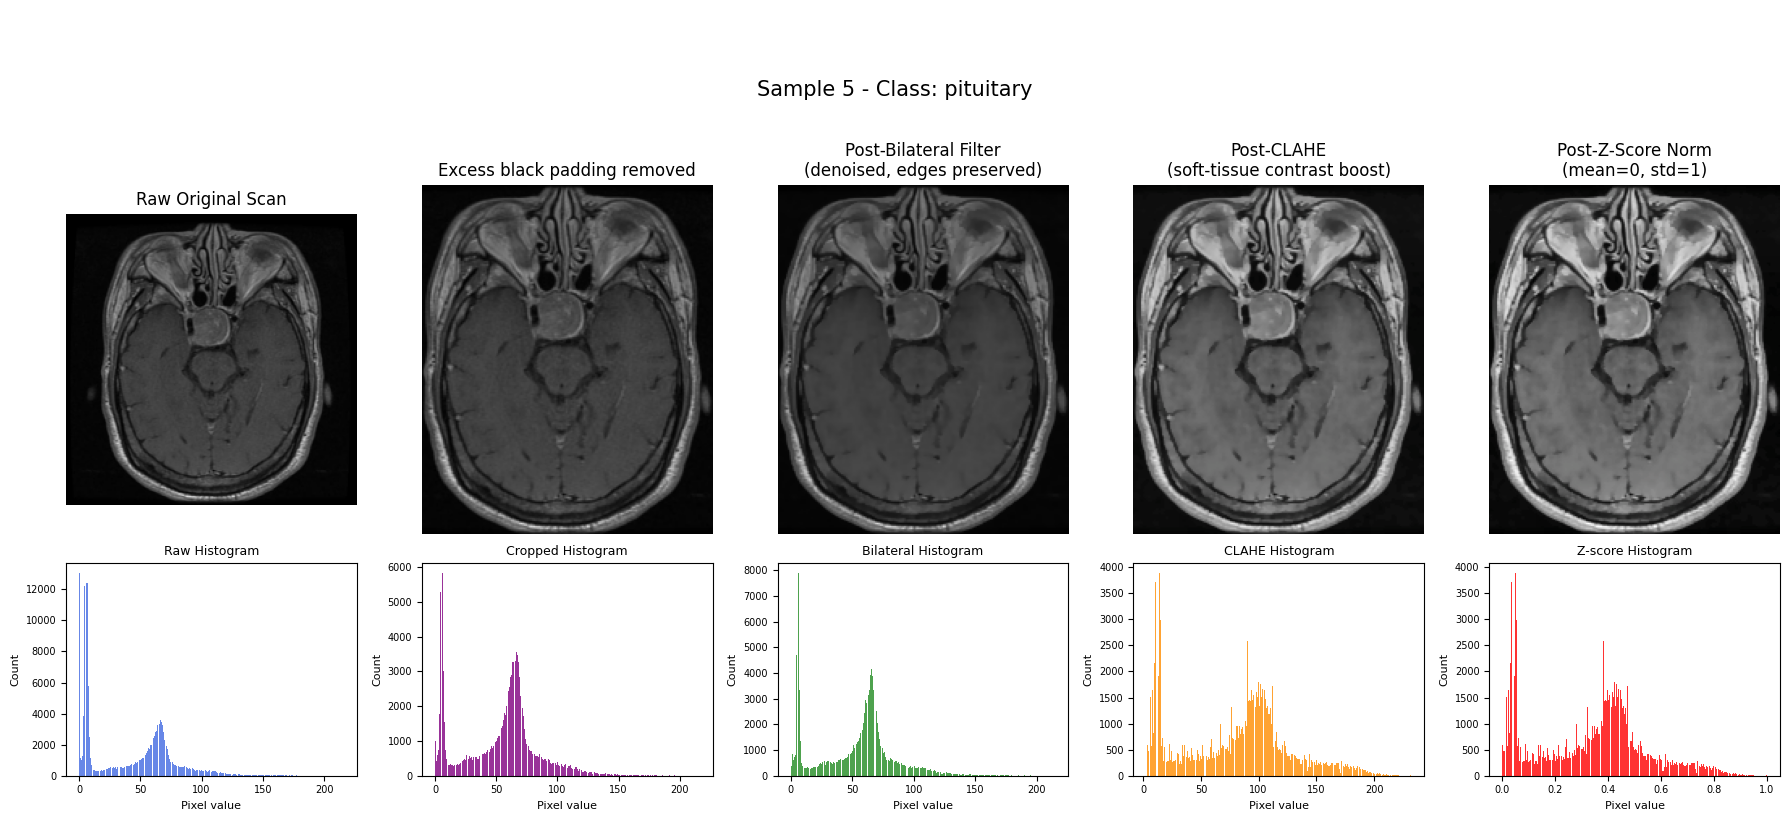

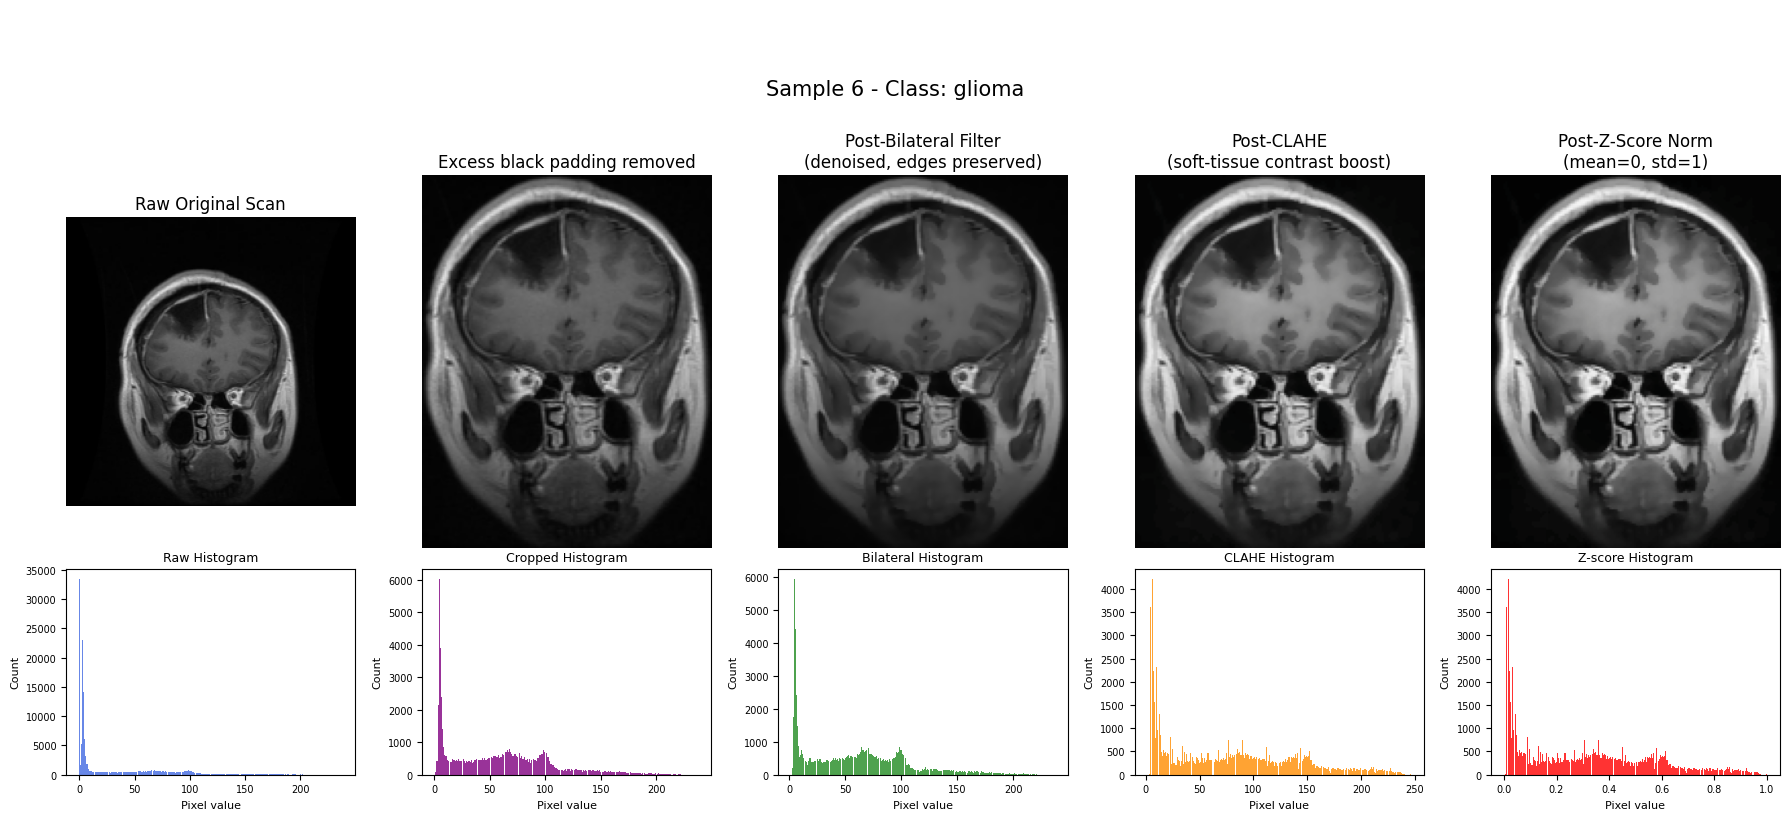

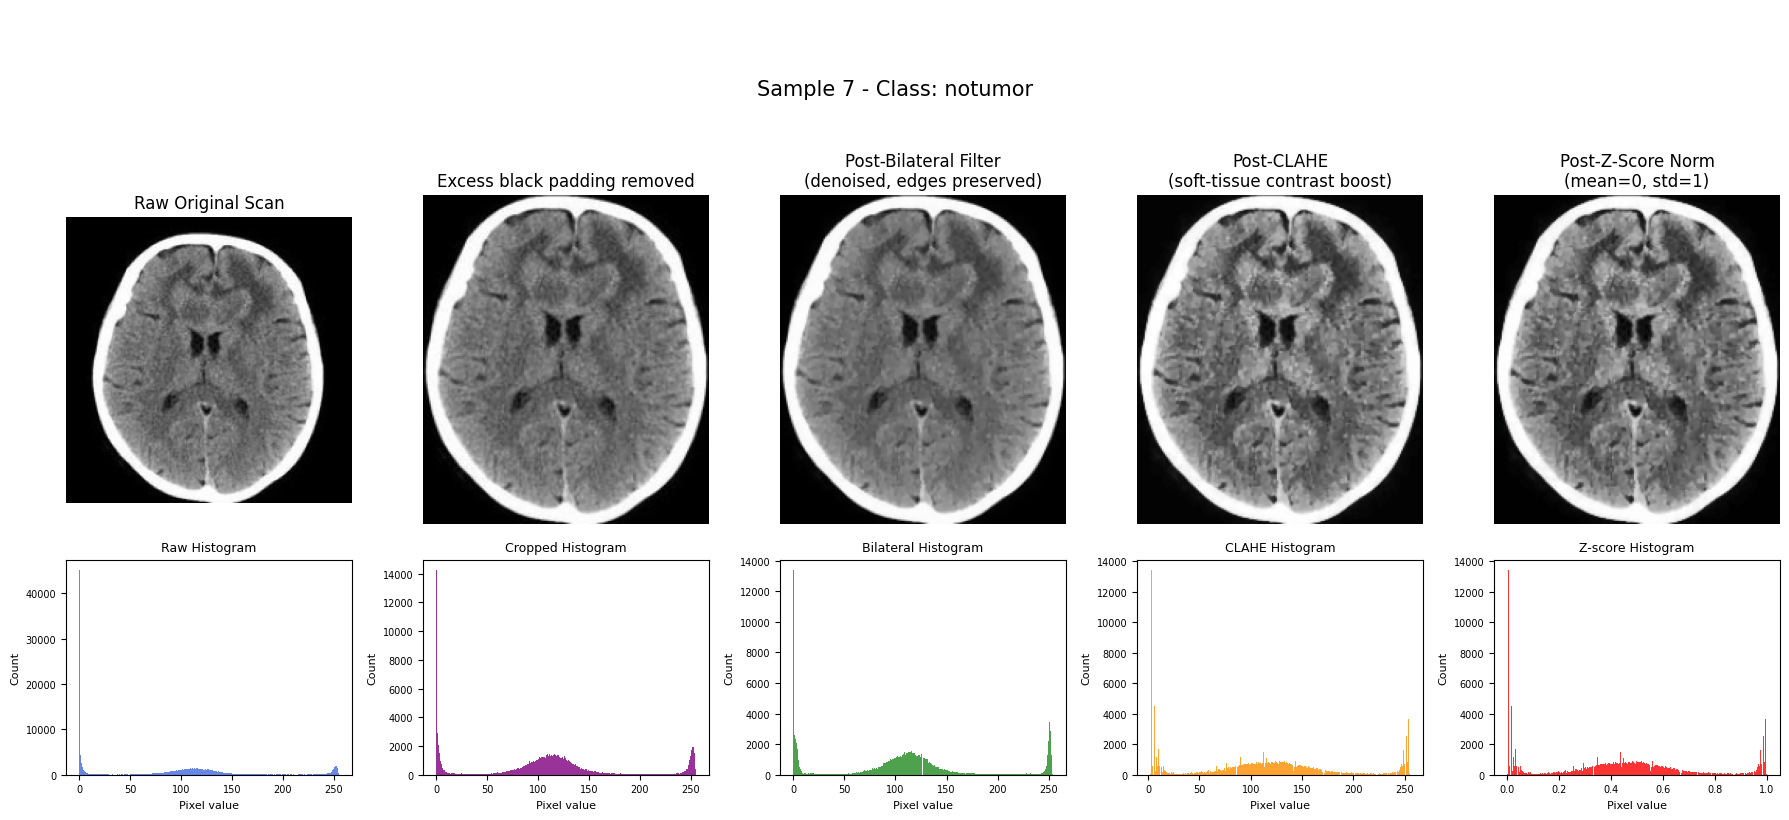

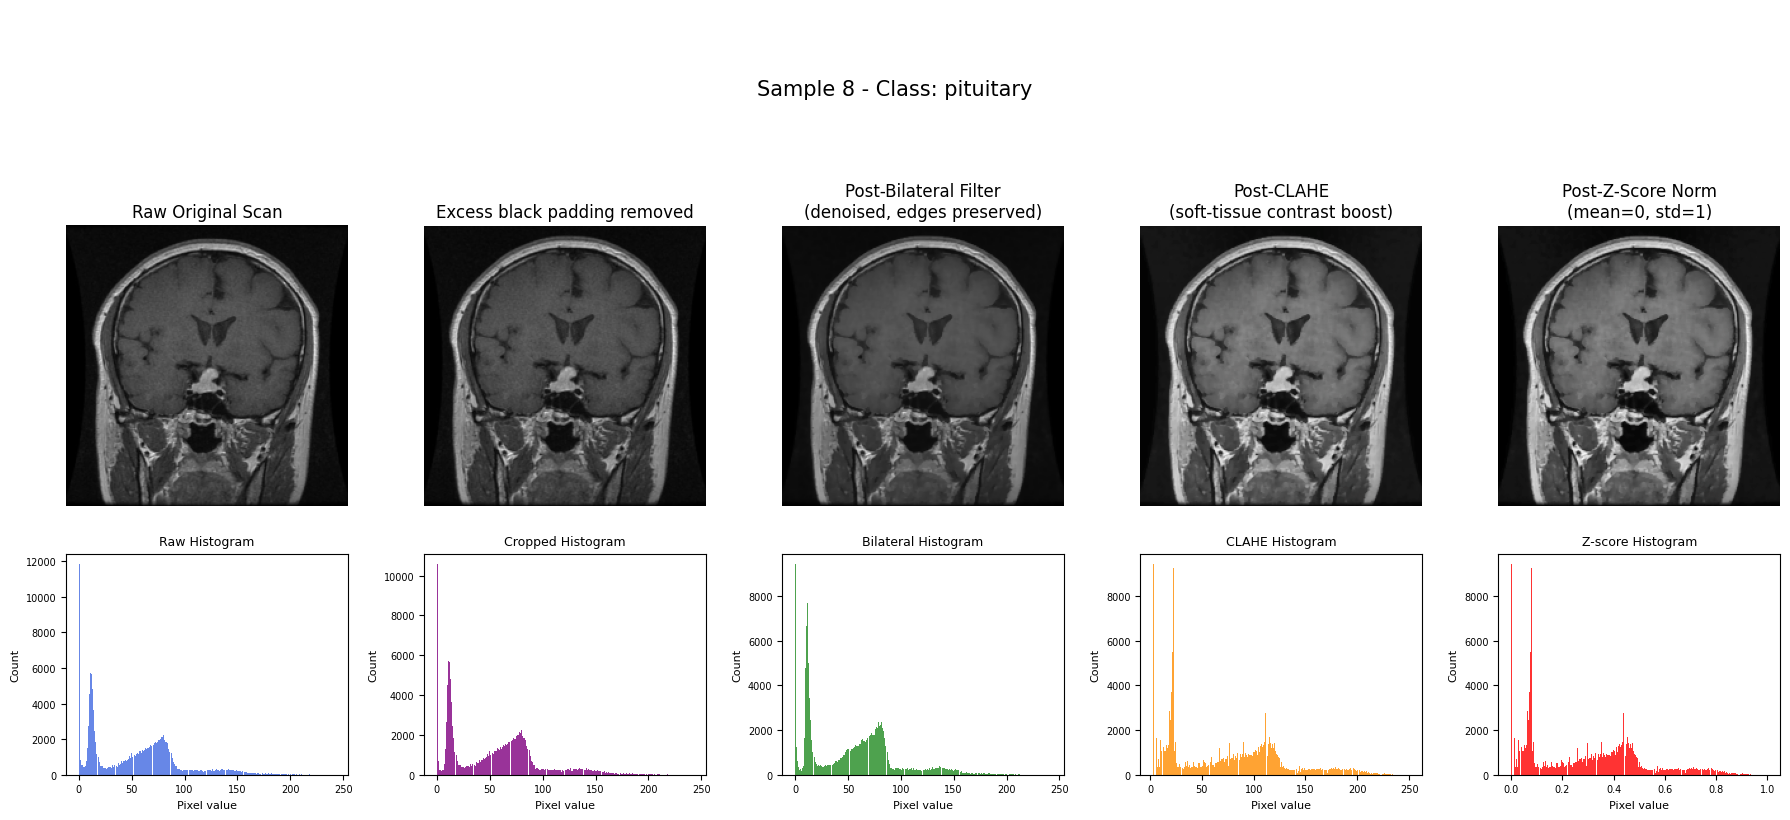

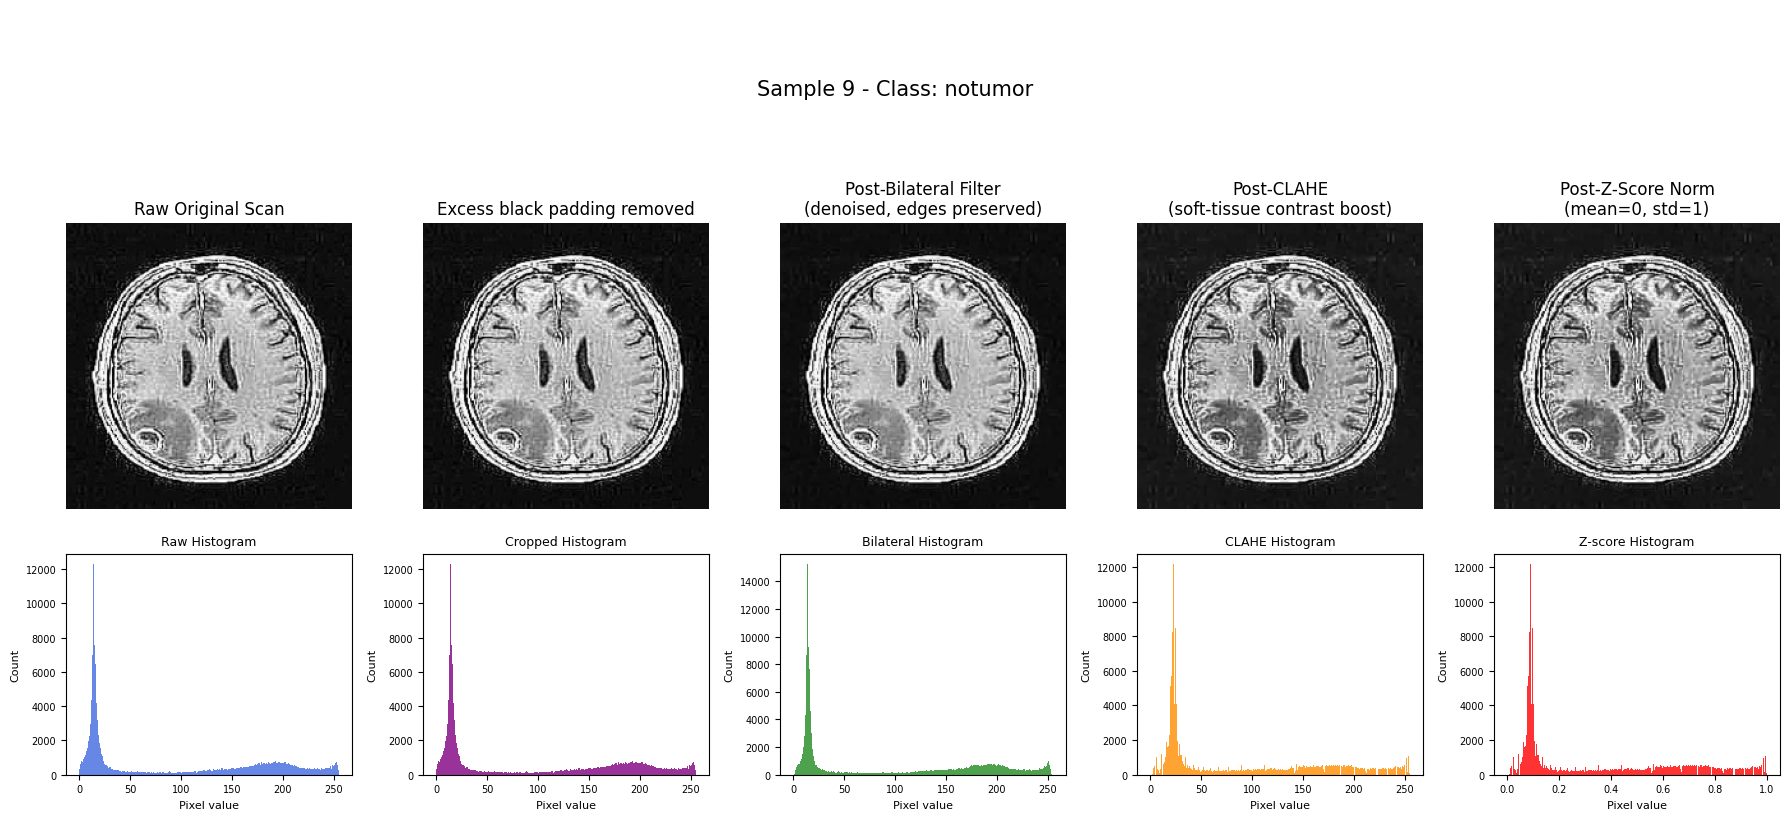

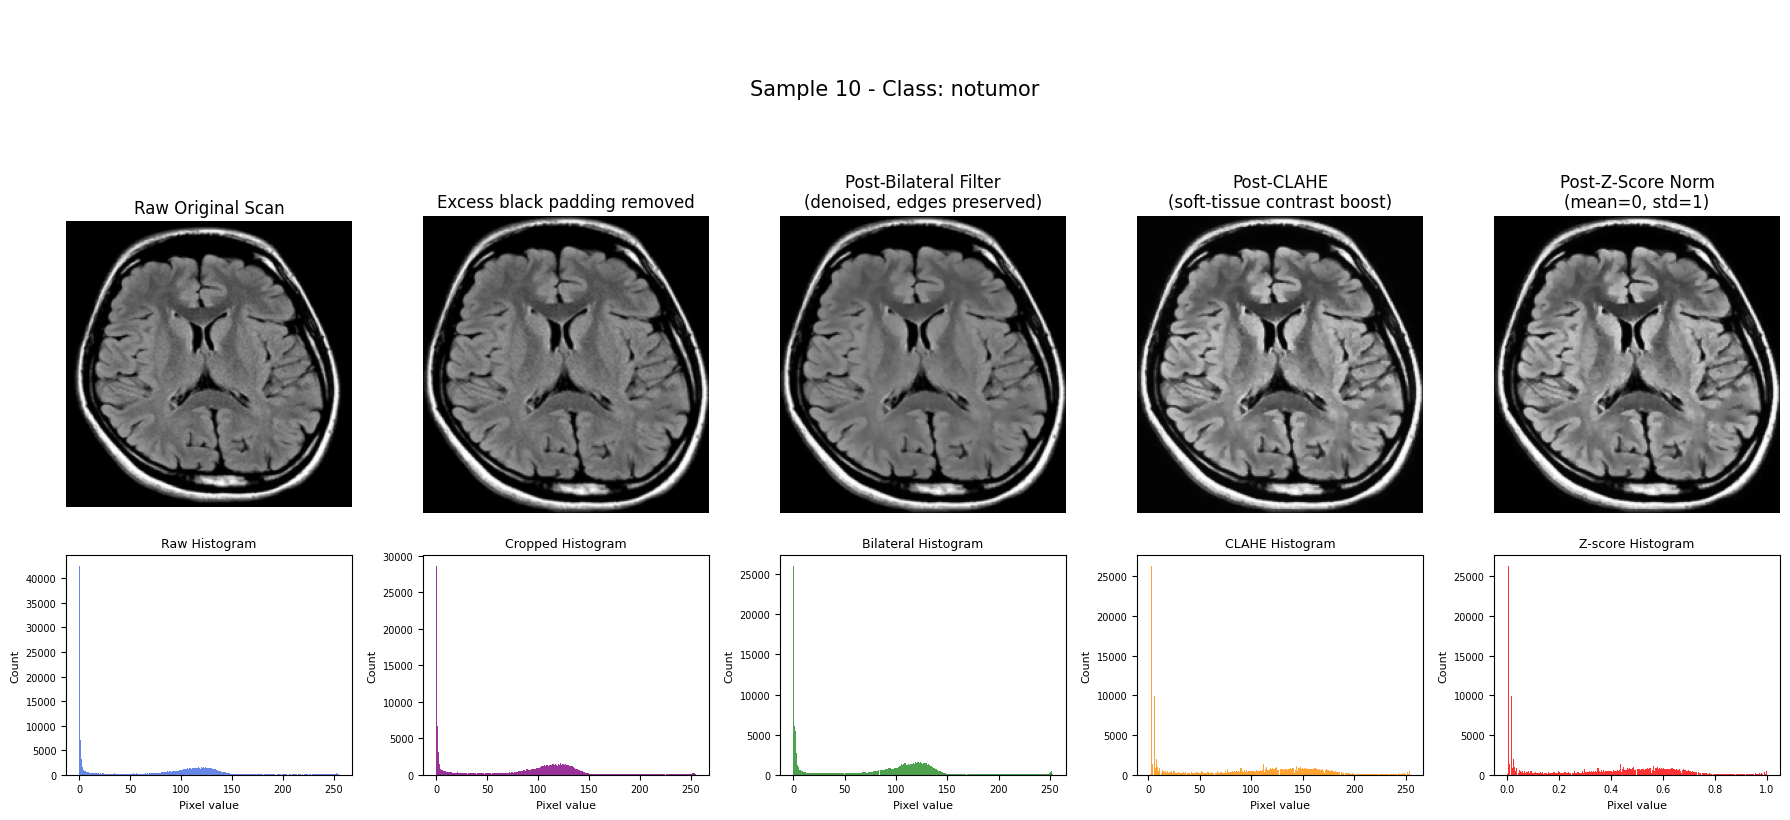

In [122]:
NUM_SAMPLES = 10
sample_df = train_df.sample(NUM_SAMPLES, random_state=CONFIG.SEED).reset_index(drop=True)

stage_colors = {
    "Raw": "royalblue",
    "Cropped": "purple",
    "Bilateral": "forestgreen",
    "CLAHE": "darkorange",
    "Z-score": "red",
}


for idx, row in sample_df.iterrows():

    filepath = row["filepath"]
    label = row["label"]

    raw = load_image(filepath)
    stages = preprocess_pipeline(raw)

    images = [
        ("Raw Original Scan", stages["raw"]),
        ("Excess black padding removed", stages["padded"]),
        ("Post-Bilateral Filter\n(denoised, edges preserved)", stages["bilateral"]),
        ("Post-CLAHE\n(soft-tissue contrast boost)", stages["clahe"]),
        ("Post-Z-Score Norm\n(mean=0, std=1)", stages["zscore"]),
    ]

    histogram_images = [
        ("Raw", stages["raw"]),
        ("Cropped", stages["padded"]),
        ("Bilateral", stages["bilateral"]),
        ("CLAHE", stages["clahe"]),
        ("Z-score", stages["zscore"]),
    ]

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(18, 8),
        gridspec_kw={"height_ratios": [2, 1]},
    )

    fig.suptitle(
        f"\n\n\nSample {idx+1} - Class: {label}",
        fontsize=15,
        y=1.02,
    )

    # Top row: images
    for ax, (title, img) in zip(axes[0], images):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

    # Bottom row: histograms
    for ax, (title, img) in zip(axes[1], histogram_images):
        plot_histogram(
            ax,
            img,
            f"{title} Histogram",
            stage_colors[title]
        )

    plt.tight_layout()
    plt.show()


## 5. Albumentations Augmentation Engine

Replaces `ImageDataGenerator`. Runs **after** the deterministic preprocessing above,
on the z-score normalized float32 tensor, so augmentation and normalization order
matches the production pipeline exactly.


In [123]:

def build_train_augmentations() -> A.Compose:
    
    """Augmentations used only for the training split. Elastic transform simulates
    soft-tissue deformation / minor scanner distortion; rotation and
    brightness/contrast jitter simulate acquisition variability across scanners."""
    
    return A.Compose([
        A.Rotate(
            limit=CONFIG.ROTATE_LIMIT_DEG,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.7,
        ),
        A.ElasticTransform(
            alpha=CONFIG.ELASTIC_ALPHA,
            sigma=CONFIG.ELASTIC_SIGMA,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5,
        ),
        A.RandomBrightnessContrast(
            brightness_limit=CONFIG.BRIGHTNESS_CONTRAST_LIMIT,
            contrast_limit=CONFIG.BRIGHTNESS_CONTRAST_LIMIT,
            p=0.5,
        ),
        A.HorizontalFlip(p=0.5),
    ])


def build_eval_augmentations() -> A.Compose:
    
    """No-op pipeline for val/test — identity transform keeps the interface
    uniform across all three Sequences."""
    
    return A.Compose([])


train_augmentor = build_train_augmentations()
eval_augmentor = build_eval_augmentations()



## 6. Visual Diagnostics — 5-Step Pipeline Grid

Pick one representative raw scan and trace it through every stage of the pipeline.


In [124]:

sample_fp = get_sample_filepath(train_df)
sample_label = train_df.loc[train_df["filepath"] == sample_fp, "label"].values[0]
print(f"Sample scan: {sample_fp}\nGround-truth class: {sample_label}")

raw_image = load_image(sample_fp)
stages = preprocess_pipeline(raw_image)

# Step 5: one augmented view of the normalized tensor (elastic + rotation)
augmented = train_augmentor(image=stages["zscore"])["image"]
stages["albumentations"] = augmented
stages["albumentations_display"] = augmented


Sample scan: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/notumor/Tr-no_265.jpg
Ground-truth class: notumor


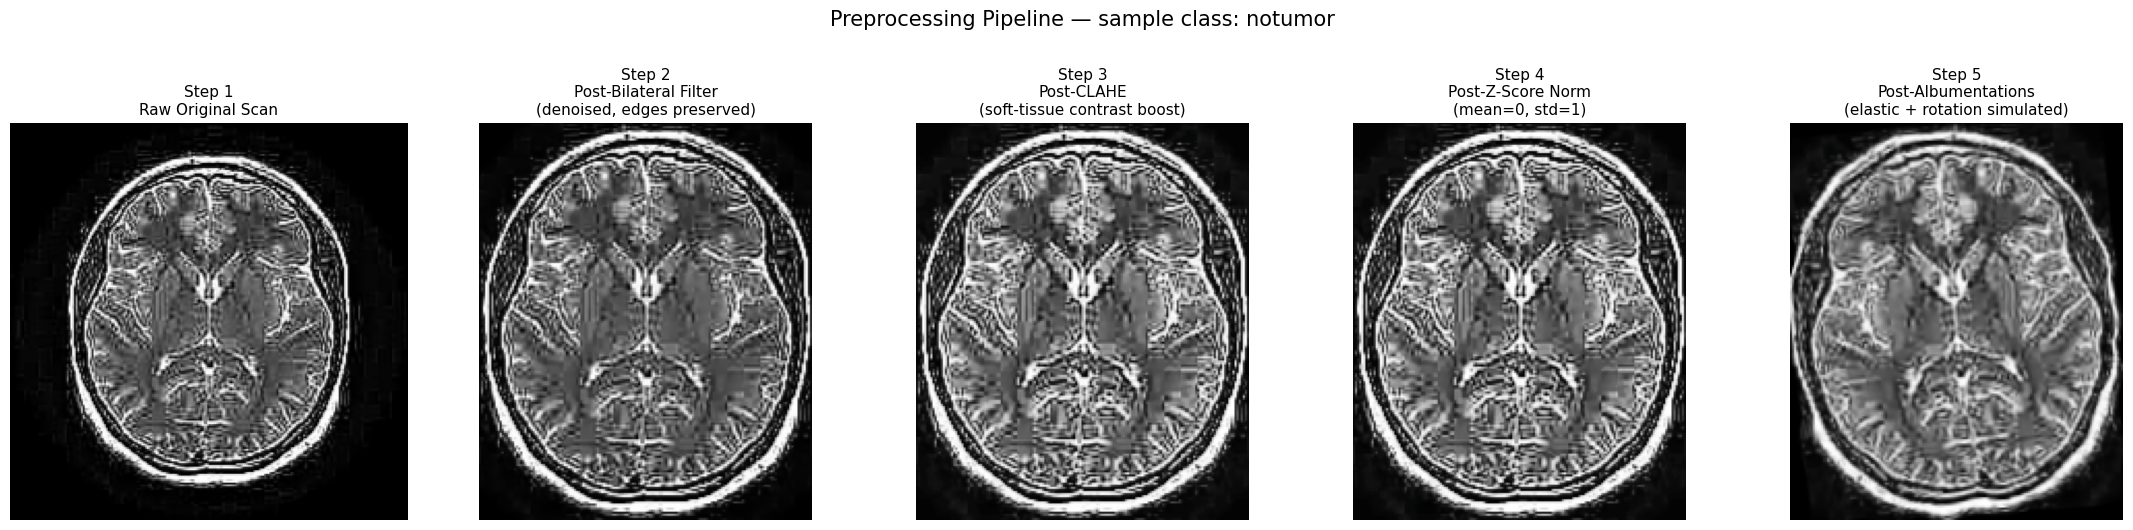

In [125]:

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

panels = [
    ("Step 1\nRaw Original Scan", stages["raw"]),
    ("Step 2\nPost-Bilateral Filter\n(denoised, edges preserved)", stages["bilateral"]),
    ("Step 3\nPost-CLAHE\n(soft-tissue contrast boost)", stages["clahe"]),
    ("Step 4\nPost-Z-Score Norm\n(mean=0, std=1)", stages["zscore"]),
    ("Step 5\nPost-Albumentations\n(elastic + rotation simulated)", stages["albumentations_display"]),
]

for ax, (title, img) in zip(axes, panels):
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

fig.suptitle(f"Preprocessing Pipeline — sample class: {sample_label}", fontsize=15, y=1.05)
plt.tight_layout()
plt.show()



## 7. Histogram Analysis — Raw vs CLAHE vs Z-Score

Demonstrates *numerically* how contrast and intensity scale shift at each stage:
CLAHE spreads the histogram across the 0–255 range, and Z-Score re-centers that
same information around 0 with unit variance.


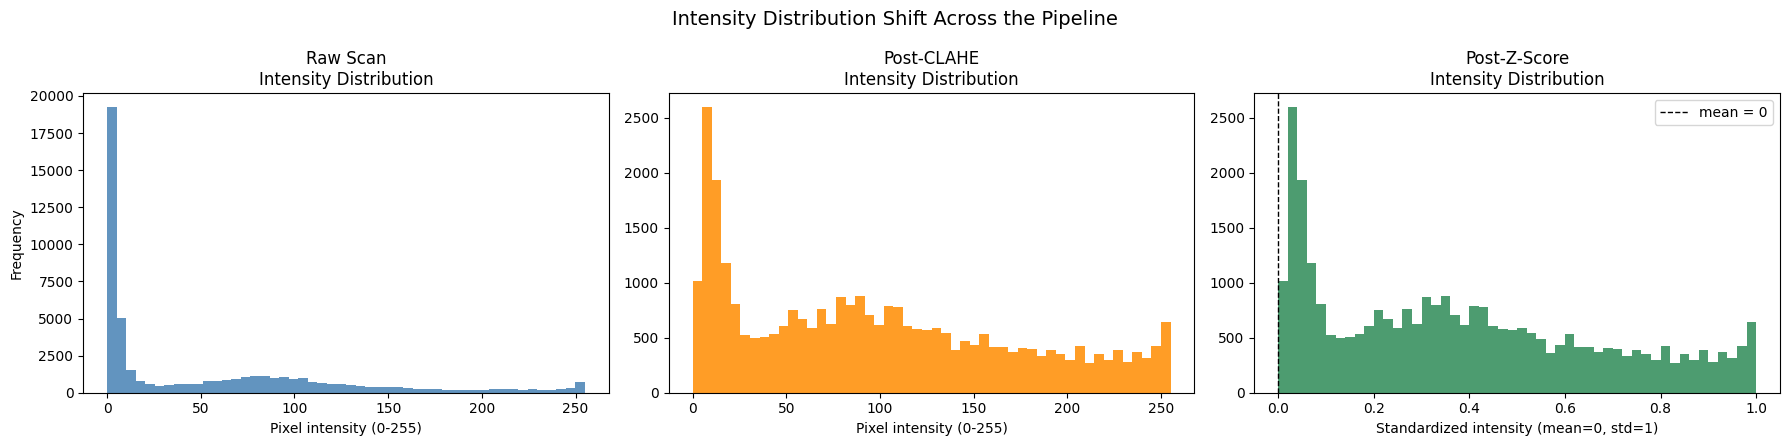

Raw    -> mean:   53.80  std:   67.56
CLAHE  -> mean:   97.94  std:   73.92
Z-Score-> mean:  0.3839  std:  0.2900


In [126]:

def flat_gray(img: np.ndarray) -> np.ndarray:
    """Convert an RGB image to a flattened grayscale intensity array for histogramming."""
    if img.ndim == 3:
        img = cv2.cvtColor(img.astype(np.float32) if img.dtype != np.uint8 else img,
                            cv2.COLOR_RGB2GRAY) if img.dtype == np.uint8 else img.mean(axis=-1)
    return img.flatten()


raw_gray = flat_gray(stages["raw"])
clahe_gray = flat_gray(stages["clahe"])
zscore_gray = stages["zscore"].mean(axis=-1).flatten()  # already float, mean across channels

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].hist(raw_gray, bins=50, color="steelblue", alpha=0.85)
axes[0].set_title("Raw Scan\nIntensity Distribution")
axes[0].set_xlabel("Pixel intensity (0-255)")
axes[0].set_ylabel("Frequency")

axes[1].hist(clahe_gray, bins=50, color="darkorange", alpha=0.85)
axes[1].set_title("Post-CLAHE\nIntensity Distribution")
axes[1].set_xlabel("Pixel intensity (0-255)")

axes[2].hist(zscore_gray, bins=50, color="seagreen", alpha=0.85)
axes[2].set_title("Post-Z-Score\nIntensity Distribution")
axes[2].set_xlabel("Standardized intensity (mean=0, std=1)")
axes[2].axvline(0, color="black", linestyle="--", linewidth=1, label="mean = 0")
axes[2].legend()

plt.suptitle("Intensity Distribution Shift Across the Pipeline", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Raw    -> mean: {raw_gray.mean():7.2f}  std: {raw_gray.std():7.2f}")
print(f"CLAHE  -> mean: {clahe_gray.mean():7.2f}  std: {clahe_gray.std():7.2f}")
print(f"Z-Score-> mean: {zscore_gray.mean():7.4f}  std: {zscore_gray.std():7.4f}")



## 8. Augmentation Grid — 3×3 Variations of the Same Slice

Confirms `ElasticTransform` introduces realistic soft-tissue-style deformation
without destroying diagnostic structures (ventricles, tumor margin, midline, etc.).


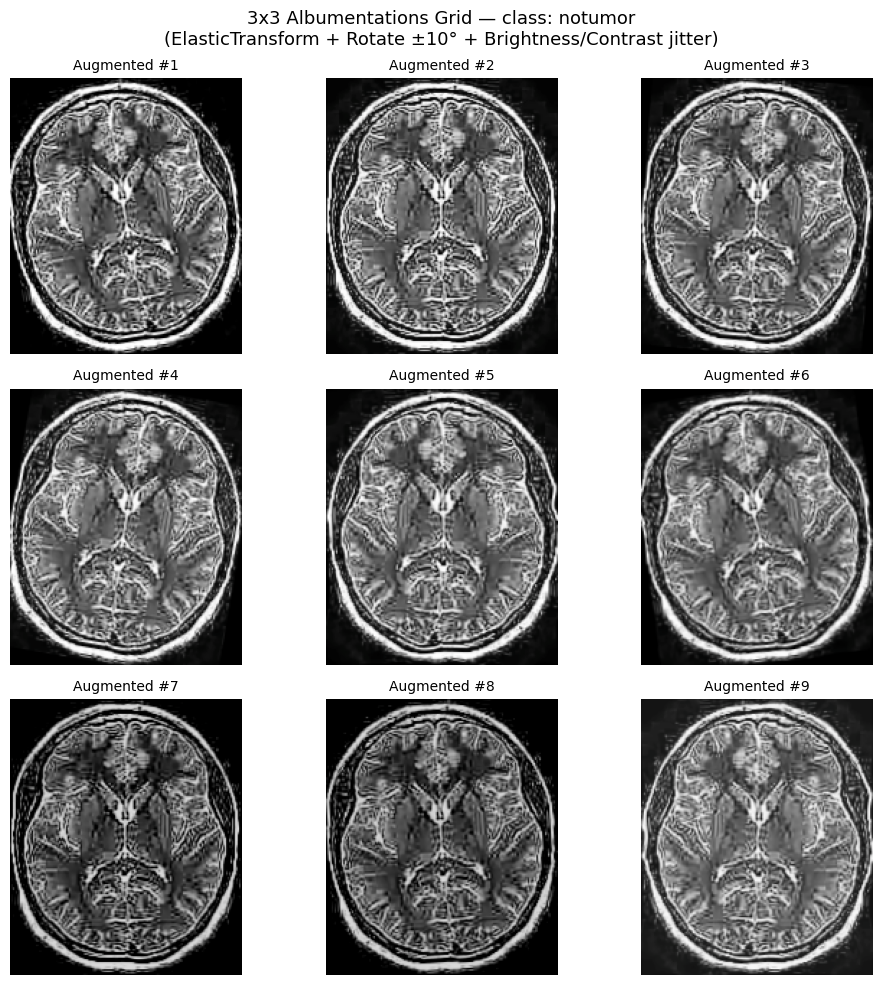

In [127]:

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

base_tensor = stages["zscore"]  # augment the same preprocessed slice 9 times

for i, ax in enumerate(axes.flat):
    aug_result = train_augmentor(image=base_tensor)["image"]
    ax.imshow(aug_result)
    ax.set_title(f"Augmented #{i + 1}", fontsize=10)
    ax.axis("off")

fig.suptitle(
    f"3x3 Albumentations Grid — class: {sample_label}\n"
    "(ElasticTransform + Rotate ±10° + Brightness/Contrast jitter)",
    fontsize=13,
)
plt.tight_layout()
plt.show()



## 9. Custom `tf.keras.utils.Sequence` — Production Data Generator

Wraps the deterministic preprocessing chain + the Albumentations engine into a
single Keras-compatible generator. `augment=True` is used for the training split
only; validation/test use the identity pipeline so metrics stay comparable run-to-run.


In [128]:
class MRIDataSequence(Sequence):
    """Keras Sequence that lazily loads, preprocesses, and (optionally) augments
    MRI slices on the fly, batch by batch."""

    def __init__(
        self,
        dataframe: pd.DataFrame,
        batch_size: int = CONFIG.BATCH_SIZE,
        img_size=CONFIG.IMG_SIZE,
        class_names=CONFIG.CLASS_NAMES,
        augment: bool = False,
        shuffle: bool = None,
        seed: int = CONFIG.SEED,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.img_size = img_size
        self.class_names = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.augment = augment
        self.shuffle = shuffle if shuffle is not None else augment
        self.seed = seed
        self.augmentor = train_augmentor if augment else eval_augmentor
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.df))
        if self.shuffle:
            # ✅ FIXED: Dynamic shuffling without fixing seed every epoch
            np.random.shuffle(self.indices)

    def __getitem__(self, batch_idx):
        batch_indices = self.indices[
            batch_idx * self.batch_size : (batch_idx + 1) * self.batch_size
        ]
        batch_df = self.df.iloc[batch_indices]

        images = np.empty((len(batch_df), *self.img_size, CONFIG.CHANNELS), dtype=np.float32)
        labels = np.empty((len(batch_df),), dtype=np.int32)

        for i, (_, row) in enumerate(batch_df.iterrows()):
            raw = load_image(row["filepath"])
            
            # 1. Crop contour first
            cropped = crop_brain_contour(raw)
            
            # Resize BACK to CONFIG.IMG_SIZE (224, 224) right after cropping!
            resized = cv2.resize(cropped, self.img_size, interpolation=cv2.INTER_AREA)
            
            # 2. Denoise and enhance contrast
            denoised = apply_bilateral_filter(resized)
            contrast_enhanced = apply_clahe_lab(denoised)
            
            # 3. Augment on [0, 255] or [0, 1] range BEFORE final normalization
            augmented = self.augmentor(image=contrast_enhanced)["image"]
            
            # 4. Normalize to [0.0, 1.0] range using hybrid Z-score
            normalized = zscore_minmax_normalize(augmented)

            images[i] = normalized
            labels[i] = self.class_to_idx[row["label"]]

        return images, to_categorical(labels, num_classes=len(self.class_names))

In [129]:

train_sequence = MRIDataSequence(train_df, augment=True, shuffle=True)
val_sequence   = MRIDataSequence(val_df,   augment=False, shuffle=False)
test_sequence  = MRIDataSequence(test_df,  augment=False, shuffle=False)

print(f"Train batches: {len(train_sequence)}")
print(f"Val batches:   {len(val_sequence)}")
print(f"Test batches:  {len(test_sequence)}")


Train batches: 180
Val batches:   23
Test batches:  23


## 10. Sanity Check — Pull One Batch End-to-End

Batch image tensor shape: (32, 224, 224, 3)
Batch label tensor shape: (32, 4)
Batch pixel stats -> mean: 0.3268, std: 0.2527


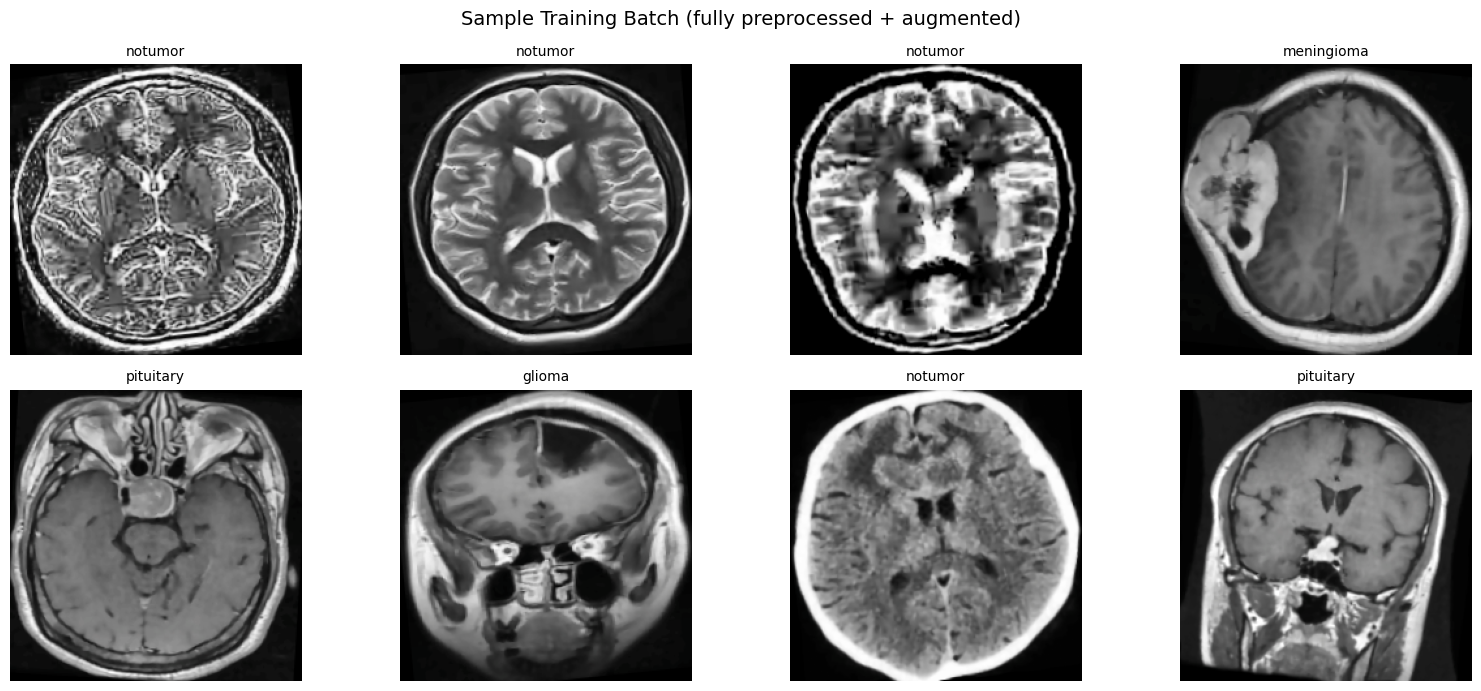

In [130]:

X_batch, y_batch = train_sequence[0]

print("Batch image tensor shape:", X_batch.shape)
print("Batch label tensor shape:", y_batch.shape)
print(f"Batch pixel stats -> mean: {X_batch.mean():.4f}, std: {X_batch.std():.4f}")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    if i >= len(X_batch):
        ax.axis("off")
        continue
    ax.imshow(X_batch[i])
    class_idx = np.argmax(y_batch[i])
    ax.set_title(CONFIG.CLASS_NAMES[class_idx], fontsize=10)
    ax.axis("off")

fig.suptitle("Sample Training Batch (fully preprocessed + augmented)", fontsize=14)
plt.tight_layout()
plt.show()



## 11. Summary & Handoff to Modeling

| Stage | Detail |
|---|---|
| Split | Stratified 80 / 10 / 10 (Train / Val / Test), class balance verified |
| Denoise | Bilateral filter, `d=9, sigmaColor=75, sigmaSpace=75` |
| Contrast | CLAHE on LAB **L-channel**, `clipLimit=2.0, tileGridSize=(8,8)` |
| Normalization | **Z-Score** (mean 0 / std 1) — replaces prior 0-1 min-max scaling |
| Augmentation | Albumentations: `Rotate(±10°)`, `ElasticTransform`, `RandomBrightnessContrast`, `HorizontalFlip` |
| Delivery | `MRIDataSequence` (Keras `Sequence`) — plug directly into `model.fit(train_sequence, validation_data=val_sequence, ...)` |

**Note for the Modeling team:** batches are `float32` with mean≈0 / std≈1 (NOT 0-1 scaled).
Make sure the first model layer does **not** include an additional `Rescaling(1./255)` step —
that would double-normalize the data.
